In [1]:
import numpy as np
import pandas as pd

#### Task 1

In [2]:
print(f'Pandas version: {pd.__version__}')

Pandas version: 2.3.2


### Load dataset

In [3]:
car_fuel = pd.read_csv('./datasets/car_fuel_efficiency.csv')
car_fuel.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


## 🚗 Car Fuel Efficiency Dataset — Column Descriptions

- 🔧 engine_displacement — Engine size/displacement (in liters or cc). Larger values generally indicate a larger engine.
- 🔢 num_cylinders — Number of cylinders in the engine (integer). Common values: 3–8; may contain missing values.
- 🐎 horsepower — Engine power in horsepower (hp). Higher values indicate more powerful engines; may contain missing values.
- ⚖️ vehicle_weight — Approximate curb weight of the vehicle (lb or kg), excluding passengers and cargo.
- ⏱️ acceleration — Time to accelerate from 0 to 60 mph, in seconds. Lower values mean quicker acceleration.
- 📆 model_year — Model year of the vehicle (four-digit year).
- 🌍 origin — Manufacturing region or market origin (e.g., USA, Europe, Asia).
- ⛽ fuel_type — Primary fuel used by the vehicle (e.g., Gasoline, Diesel).
- 🚙 drivetrain — Drivetrain configuration (e.g., Front-wheel drive, All-wheel drive).
- 🚪 num_doors — Number of passenger doors (integer; typically 2, 3, 4, or 5). Note: the dataset may include placeholder/atypical values (e.g., 0 or negatives).
- 🌿 fuel_efficiency_mpg — Fuel economy in miles per gallon (mpg). Higher values indicate better efficiency.

#### Task 2

In [4]:
print(f'Dataset has {car_fuel.shape[0]} records')

Dataset has 9704 records


#### Task 3

In [5]:
fuel_types = car_fuel["fuel_type"].value_counts()
fuel_types

fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64

In [6]:
len(fuel_types)

2

There are only two types of fuel: gasoline and diesel

#### Task 4

In [7]:
car_fuel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [8]:
car_fuel.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

There are 4 columns that contain missing values

#### Task 5

In [9]:
car_fuel["origin"].value_counts()

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64

Fuel produced in Asia

In [10]:
asia_fuel = car_fuel.loc[car_fuel["origin"] == "Asia"]
asia_fuel.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
8,250,1.0,174.0,2714.219310,10.3,2016,Asia,Diesel,Front-wheel drive,-1.0,16.823554
12,320,5.0,145.0,2783.868974,15.1,2010,Asia,Diesel,All-wheel drive,1.0,16.175820
14,200,6.0,160.0,3582.687368,14.9,2007,Asia,Diesel,All-wheel drive,0.0,11.871091
20,150,3.0,197.0,2231.808142,18.7,2011,Asia,Gasoline,Front-wheel drive,1.0,18.889083
21,160,4.0,133.0,2659.431451,NaN,2016,Asia,Gasoline,Front-wheel drive,-1.0,16.077730


In [11]:
print(f'The most efficient fuel from Asia has {asia_fuel["fuel_efficiency_mpg"].max().round(2)} mpg')

The most efficient fuel from Asia has 23.76 mpg


#### Task 6

In [12]:
med_horse_pw = car_fuel["horsepower"].median()
med_horse_pw

np.float64(149.0)

In [13]:
freq_horse_pw = car_fuel["horsepower"].value_counts().idxmax()
freq_horse_pw

np.float64(152.0)

In [14]:
new_horse_pw = car_fuel["horsepower"].fillna(freq_horse_pw)
med_new_horse_pw = new_horse_pw.median()
med_new_horse_pw

np.float64(152.0)

In [15]:
print("Yes, it increased" if med_new_horse_pw > med_horse_pw else (
    "Yes, it decreased" if med_new_horse_pw < med_horse_pw else "No"
    ))

Yes, it increased


#### Task 7

In [16]:
sample = asia_fuel[["vehicle_weight", "model_year"]].head(7)
sample


,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [17]:
X = np.array(sample)
X

array([[2714.21930965, 2016.        ],
       [2783.86897424, 2010.        ],
       [3582.68736772, 2007.        ],
       [2231.8081416 , 2011.        ],
       [2659.43145076, 2016.        ],
       [2844.22753389, 2014.        ],
       [3761.99403819, 2019.        ]])

In [18]:
XTX = X.T @ X
XTX

array([[62248334.33150762, 41431216.5073268 ],
       [41431216.5073268 , 28373339.        ]])

In [19]:
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
w = np.linalg.inv(XTX) @ X.T @ y
w

array([0.01386421, 0.5049067 ])

In [20]:
print(f'Result: {w.sum()}')

Result: 0.5187709081074016


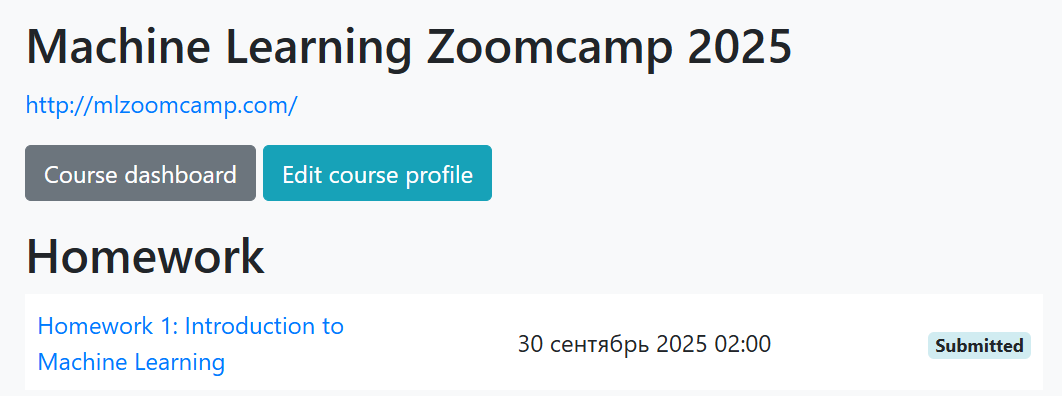

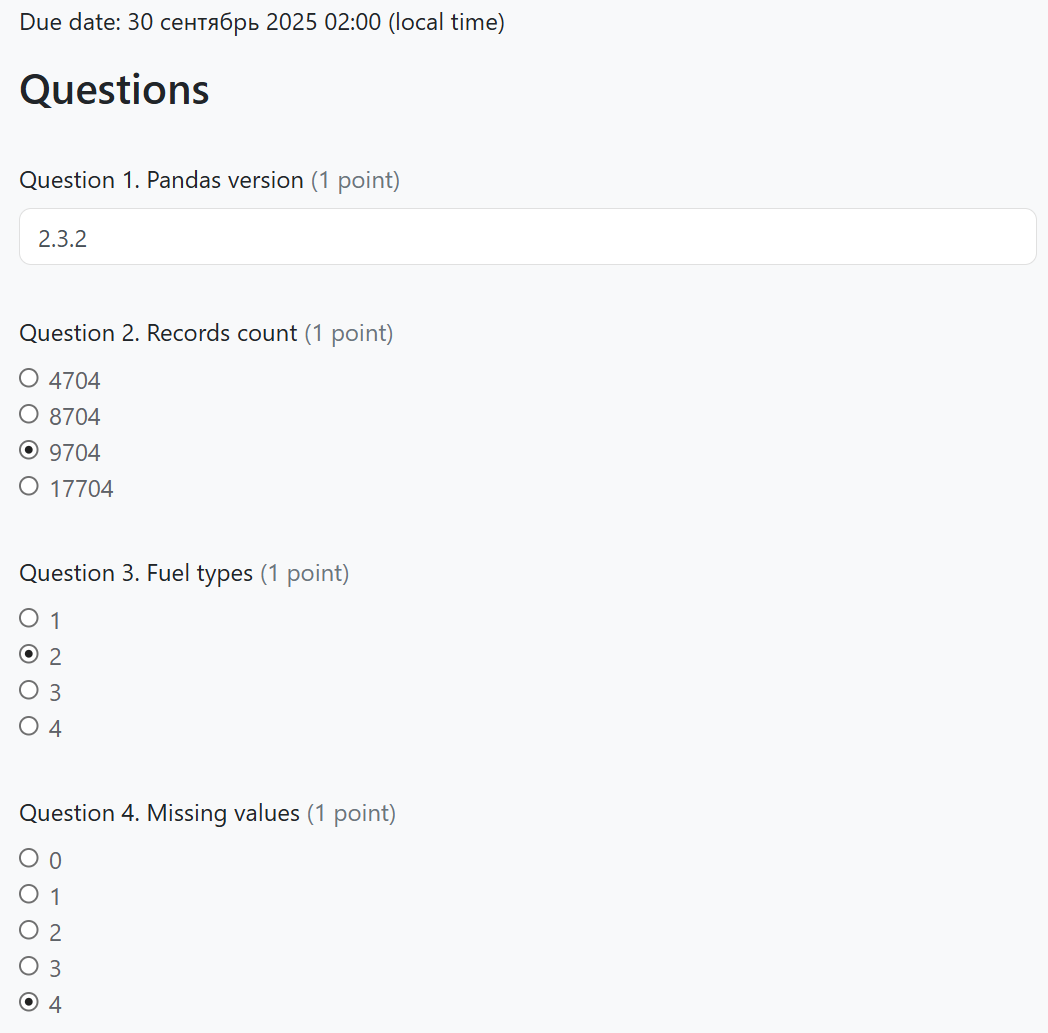
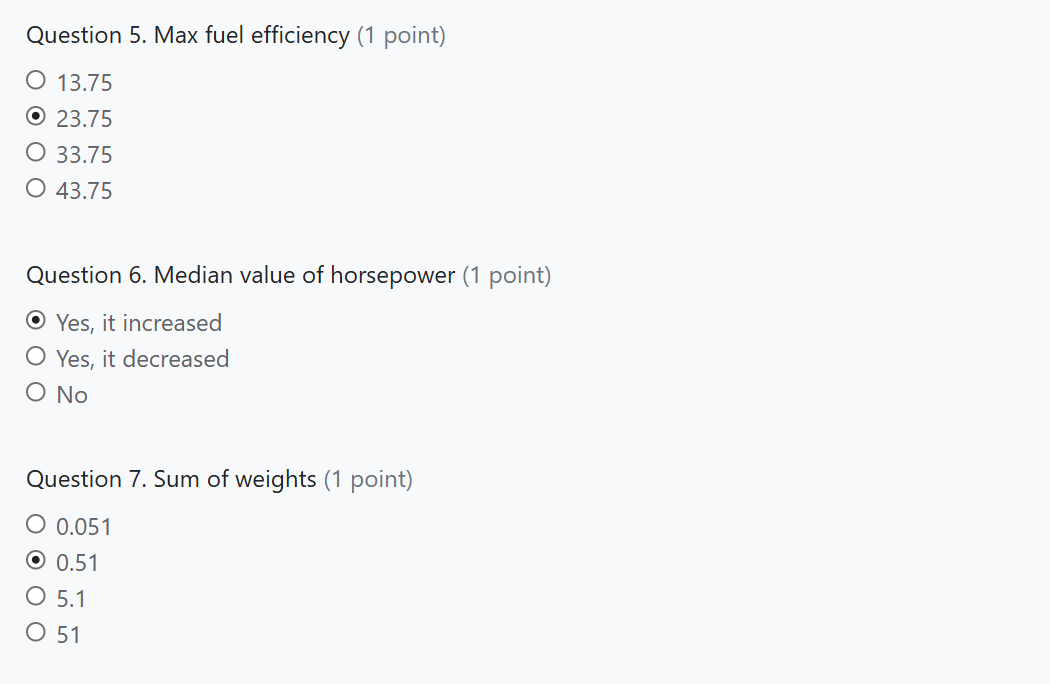